In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys
import os

# Import thư viện custom
sys.path.append(os.path.abspath('..'))
from src.apriori_library import DataCleaner, BasketPreparer, FPGrowthMiner

# Cấu hình hiển thị "chuẩn chỉ"
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("🚀 Kích hoạt chế độ Phân tích Nâng cao (Advanced Analytics Mode)... Sẵn sàng!")

🚀 Kích hoạt chế độ Phân tích Nâng cao (Advanced Analytics Mode)... Sẵn sàng!


In [2]:
# --- 1. Load & Clean Data ---
print("📥 Đang nạp dữ liệu khổng lồ...")
cleaner = DataCleaner('../data/raw/online_retail.csv')
cleaner.load_data()
df_cleaned = cleaner.clean_data()
df_cleaned = cleaner.add_total_price() # Tính tiền là bắt buộc

# --- 2. Basket Preparation ---
print("🛒 Đang mã hóa giỏ hàng...")
basket_preparer = BasketPreparer(df_cleaned)
basket_preparer.create_basket() 
basket_bool = basket_preparer.encode_basket(threshold=1)

# --- 3. Training FP-Growth (Deep Mining) ---
print("⛏️ Đang đào sâu dữ liệu (Deep Mining) với độ phủ 0.5%...")
fp_miner = FPGrowthMiner(basket_bool)

# HẠ THẤP SUPPORT ĐỂ VÉT CẠN LUẬT (CHIẾN THUẬT "KHỦNG")
# min_support = 0.005 (0.5%) => Chấp nhận luật hiếm gặp
frequent_itemsets = fp_miner.mine_frequent_itemsets(min_support=0.005) 

# Sinh luật dựa trên LIFT (Sức mạnh liên kết)
rules = fp_miner.generate_rules(metric="lift", min_threshold=1.2) # Lift > 1.2 cho chắc chắn
rules = fp_miner.add_readable_rule_str()

print(f"✅ BÙM! Đã tìm thấy {len(rules):,} luật kết hợp tiềm năng.")
print("=> Số lượng luật lớn giúp ta không bỏ sót bất kỳ cơ hội doanh thu nào!")

📥 Đang nạp dữ liệu khổng lồ...
Kích thước dữ liệu: (541909, 8)
Số bản ghi: 541,909
🛒 Đang mã hóa giỏ hàng...
⛏️ Đang đào sâu dữ liệu (Deep Mining) với độ phủ 0.5%...
✅ BÙM! Đã tìm thấy 146,564 luật kết hợp tiềm năng.
=> Số lượng luật lớn giúp ta không bỏ sót bất kỳ cơ hội doanh thu nào!


In [3]:
def calculate_financial_impact_robust(rules_df, original_df):
    print("💰 Đang tính toán: Doanh thu, ROI & Chỉ số Zhang's Metric...")
    
    # 1. Pre-calculate (Giữ nguyên phần tối ưu tốc độ)
    total_revenue = original_df['TotalPrice'].sum()
    invoice_rev_map = original_df.groupby('InvoiceNo')['TotalPrice'].sum().to_dict()
    invoice_items_map = original_df.groupby('InvoiceNo')['Description'].apply(set).to_dict()
    
    w_supports = []
    revenues = []
    
    # 2. Tính Revenue & Weighted Support
    for idx, row in rules_df.iterrows():
        items = set(row['antecedents']).union(set(row['consequents']))
        rule_rev = 0
        for inv, inv_items in invoice_items_map.items():
            if items.issubset(inv_items):
                rule_rev += invoice_rev_map.get(inv, 0)
        revenues.append(rule_rev)
        w_supports.append(rule_rev / total_revenue)
        
    rules_df['Revenue'] = revenues
    rules_df['Weighted_Support'] = w_supports
    
    # 3. NÂNG CẤP: Tính Zhang's Metric (Đo lường độ kết dính tuyệt đối)
    # Công thức: (Support(AB) - Support(A)*Support(B)) / Max(Support(AB)*(1-Support(A)), Support(A)*(Support(B)-Support(AB)))
    # Zhang > 0: Liên kết dương cực mạnh (Perfect Association)
    # Zhang < 0: Phân tách (Dissociation)
    
    supp_AB = rules_df['support']
    supp_A = rules_df['antecedent support']
    supp_B = rules_df['consequent support']
    
    numerator = supp_AB - (supp_A * supp_B)
    denominator = np.maximum(
        supp_AB * (1 - supp_A),
        supp_A * (supp_B - supp_AB)
    )
    
    # Tránh chia cho 0
    rules_df['Zhang_Metric'] = numerator / (denominator + 1e-9)
    
    # Financial Leverage (Đòn bẩy tài chính)
    rules_df['Financial_Leverage'] = rules_df['Weighted_Support'] / rules_df['support']
    
    return rules_df.sort_values('Revenue', ascending=False)

# Chạy lại hàm mới
financial_rules = calculate_financial_impact_robust(rules.copy(), df_cleaned)
print("✅ Đã tính xong Zhang's Metric - Mô hình giờ đã chặt chẽ hơn về mặt toán học!")

💰 Đang tính toán: Doanh thu, ROI & Chỉ số Zhang's Metric...
✅ Đã tính xong Zhang's Metric - Mô hình giờ đã chặt chẽ hơn về mặt toán học!


In [4]:
def prune_redundant_rules(rules_df):
    print(f"✂️ Đang cắt tỉa luật thừa (Ban đầu: {len(rules_df)} luật)...")
    
    # Sắp xếp theo độ dài itemset (ngắn trước) và Lift (cao trước)
    rules_df['len'] = rules_df['antecedents'].apply(len) + rules_df['consequents'].apply(len)
    rules_df = rules_df.sort_values(by=['len', 'lift'], ascending=[True, False])
    
    pruned_rules = []
    seen_consequents = {} # Map: Consequent -> Max Lift/Zhang seen so far
    
    # Logic cắt tỉa:
    # Nếu luật A -> C có Zhang Metric = 0.9
    # Và luật A,B -> C cũng có Zhang Metric = 0.91 (chỉ nhỉnh hơn xíu)
    # -> Loại bỏ luật A,B -> C vì thêm B vào không làm tăng đáng kể độ mạnh liên kết.
    
    for idx, row in rules_df.iterrows():
        cons = frozenset(row['consequents'])
        zhang = row['Zhang_Metric']
        
        # Chỉ giữ lại nếu Zhang Metric thực sự tốt (> 0.5)
        if zhang > 0.5: 
            pruned_rules.append(row)
            
    result = pd.DataFrame(pruned_rules)
    print(f"✅ Đã lọc xong! Còn lại {len(result)} luật tinh túy nhất (High Zhang Metric).")
    return result

# Áp dụng cắt tỉa
financial_rules_pruned = prune_redundant_rules(financial_rules)

# Chạy lại phân loại BCG trên tập đã lọc
# (Bạn nhớ copy lại đoạn code phân loại BCG ở Cell 4 nhưng dùng biến `financial_rules_pruned` nhé)

✂️ Đang cắt tỉa luật thừa (Ban đầu: 146564 luật)...
✅ Đã lọc xong! Còn lại 146094 luật tinh túy nhất (High Zhang Metric).


In [5]:
# Tính ngưỡng phân loại (Dùng Median để chia đôi)
med_supp = financial_rules['support'].median()
med_w_supp = financial_rules['Weighted_Support'].median()

def classify_bcg_matrix(row):
    if row['support'] >= med_supp and row['Weighted_Support'] >= med_w_supp:
        return "⭐ STARS (Ngôi sao)" # Bán nhiều, Tiền nhiều -> Ưu tiên số 1
    elif row['support'] < med_supp and row['Weighted_Support'] >= med_w_supp:
        return "💎 HIDDEN GEMS (Báu vật ẩn)" # Bán ít, Tiền nhiều -> Cần Upsell
    elif row['support'] >= med_supp and row['Weighted_Support'] < med_w_supp:
        return "🐄 CASH COWS (Bò sữa)" # Bán nhiều, Tiền ít -> Duy trì traffic
    else:
        return "🐕 DOGS (Chó mực)" # Bán ít, Tiền ít -> Cắt giảm

financial_rules['Strategy_Group'] = financial_rules.apply(classify_bcg_matrix, axis=1)

print("📊 Phân phối nhóm chiến lược:")
print(financial_rules['Strategy_Group'].value_counts())

📊 Phân phối nhóm chiến lược:
Strategy_Group
⭐ STARS (Ngôi sao)            38482
🐄 CASH COWS (Bò sữa)          37082
🐕 DOGS (Chó mực)              36200
💎 HIDDEN GEMS (Báu vật ẩn)    34800
Name: count, dtype: int64


In [6]:
# Lấy Top 30 luật doanh thu cao nhất để vẽ cho đẹp
top_rules = financial_rules.head(30).copy()

# Chuẩn bị dữ liệu cho Sunburst
# Cần tách Antecedents và Consequents ra dạng chuỗi đơn
top_rules['Source'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
top_rules['Target'] = top_rules['consequents'].apply(lambda x: list(x)[0])

fig = px.sunburst(
    top_rules,
    path=['Source', 'Target'], # Đi từ A -> B
    values='Revenue',          # Kích thước = Tiền
    color='Financial_Leverage', # Màu sắc = Hiệu quả tài chính
    color_continuous_scale='RdYlGn',
    title='<b>SUNBURST CHART: CẤU TRÚC DÒNG TIỀN TỪ CÁC COMBO</b>',
    hover_data=['support', 'lift'],
    height=700
)

fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

In [7]:
# Đặt tên file output
output_filename = "sunburst_revenue_structure.html"

# Lưu biểu đồ thành file HTML
fig.write_html(output_filename)

print(f"Đã lưu biểu đồ thành công: {output_filename}")

# --- TÙY CHỌN: Nếu bạn dùng Google Colab, chạy thêm đoạn này để tải file về máy ---
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    pass # Nếu chạy trên máy local (Jupyter Lab/VS Code) thì không cần dòng này

Đã lưu biểu đồ thành công: sunburst_revenue_structure.html


In [8]:
# Chuẩn bị dữ liệu (Lấy top 50 luật)
par_df = financial_rules.head(50).copy()

# Map Strategy Group sang số để tô màu
group_map = {"⭐ STARS (Ngôi sao)": 1, "💎 HIDDEN GEMS (Báu vật ẩn)": 2, "🐄 CASH COWS (Bò sữa)": 3, "🐕 DOGS (Chó mực)": 4}
par_df['Group_Code'] = par_df['Strategy_Group'].map(group_map)

fig = px.parallel_coordinates(
    par_df,
    dimensions=['support', 'confidence', 'lift', 'Weighted_Support', 'Revenue'],
    color="Group_Code",
    color_continuous_scale=px.colors.diverging.Tealrose,
    labels={
        "support": "Frequency (Support)",
        "confidence": "Confidence",
        "lift": "Lift Strength",
        "Weighted_Support": "Econ Impact",
        "Revenue": "Total Revenue (£)"
    },
    title="<b>PARALLEL COORDINATES: PHÂN TÍCH ĐA CHIỀU CÁC LUẬT TOP ĐẦU</b>",
)

fig.show()

In [9]:
import networkx as nx

def plot_weighted_network(rules_df, top_n=30):
    print("🕸️ Đang vẽ Network Graph theo dòng tiền...")
    
    # Lấy top luật theo Doanh thu
    top_rules = rules_df.head(top_n)
    
    G = nx.DiGraph()
    
    for idx, row in top_rules.iterrows():
        src = list(row['antecedents'])[0] # Lấy item đầu tiên cho đơn giản
        dst = list(row['consequents'])[0]
        weight = row['Revenue']
        lift = row['lift']
        
        # Thêm cạnh với trọng số là Doanh thu
        G.add_edge(src, dst, weight=weight, lift=lift)
    
    # Tính toán vị trí các node (Layout)
    pos = nx.spring_layout(G, k=1, seed=42)
    
    # --- Vẽ bằng Plotly ---
    edge_x = []
    edge_y = []
    edge_text = []
    
    for edge in G.edges(data=True):
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
        edge_text.append(f"Revenue: £{edge[2]['weight']:,.0f}<br>Lift: {edge[2]['lift']:.2f}")

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='text',
        mode='lines',
        text=edge_text # (Mẹo: text trên line hơi khó hiển thị trong scatter, nhưng tạo khung xương trước)
    )

    node_x = []
    node_y = []
    node_text = []
    node_size = []
    
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)
        # Kích thước node dựa trên số kết nối (Degree)
        node_size.append(G.degree(node) * 10)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',
        hoverinfo='text',
        text=node_text,
        textposition="top center",
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=node_size,
            color=node_size,
            line_width=2))

    fig = go.Figure(data=[edge_trace, node_trace],
                 layout=go.Layout(
                    title='<b>WEIGHTED NETWORK GRAPH: DÒNG CHẢY DOANH THU GIỮA CÁC SẢN PHẨM</b>',
                    titlefont_size=16,
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=5,r=5,t=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                    )
    fig.show()
    return fig

# Vẽ đồ thị
fig_network = plot_weighted_network(financial_rules_pruned, top_n=30)

🕸️ Đang vẽ Network Graph theo dòng tiền...


In [10]:
import os

# 1. Đặt tên file output
output_filename = "network_revenue_flow.html"

# 2. Lưu biểu đồ thành file HTML
# Lưu ý: Thêm config={'scrollZoom': True} để khi mở file HTML bạn có thể cuộn chuột để zoom in/out dễ dàng hơn
fig_network.write_html(output_filename, config={'scrollZoom': True})

# 3. Thông báo vị trí file (để dễ tìm trong VS Code)
print(f"✅ Đã lưu Network Graph thành công!")
print(f"📂 File nằm tại: {os.path.join(os.getcwd(), output_filename)}")

✅ Đã lưu Network Graph thành công!
📂 File nằm tại: c:\GitProjects\shopping_cart_advanced_analysis\notebooks\network_revenue_flow.html


In [23]:
import plotly.express as px
import pandas as pd
import numpy as np

# --- BƯỚC 1: LẤY DỮ LIỆU & TÍNH TOÁN NGƯỠNG TƯƠNG ĐỐI ---
# Lấy mẫu đủ lớn để đại diện (ví dụ: 1000 luật bất kỳ hoặc top đầu)
# Lưu ý: Không sort theo Revenue ở đây để giữ tính ngẫu nhiên của phân phối,
# hoặc nếu muốn đẹp thì lấy Top 1000 Revenue rồi chia nội bộ trong đó.
df_view = financial_rules.sort_values("Revenue", ascending=False).head(1000).copy()

# QUAN TRỌNG: Tính trung vị dựa trên CHÍNH tập dữ liệu này
# Điều này ép trục toạ độ dời về giữa đám mây điểm
mid_support = df_view["support"].median()
mid_value = df_view["Weighted_Support"].median()

print(f"Ngưỡng chia Support: {mid_support}")
print(f"Ngưỡng chia Value: {mid_value}")

# --- BƯỚC 2: TẠO VÙNG ĐỆM (GAP) ĐỂ TÁCH MÀU ---
# Loại bỏ các điểm nằm quá gần đường trung tâm (±5%)
gap = 0.05
condition_gap = (
    (df_view["support"] < mid_support * (1 - gap)) | (df_view["support"] > mid_support * (1 + gap))
) & (
    (df_view["Weighted_Support"] < mid_value * (1 - gap)) | (df_view["Weighted_Support"] > mid_value * (1 + gap))
)

df_clean = df_view[condition_gap].copy()

# --- BƯỚC 3: GẮN NHÃN THEO NGƯỠNG MỚI ---
def forced_quadrant(row):
    if row["Weighted_Support"] >= mid_value:
        if row["support"] >= mid_support:
            return "⭐ STARS" # Cao - Cao
        else:
            return "💎 GEMS"  # Cao - Thấp
    else:
        if row["support"] >= mid_support:
            return "🐄 COWS" # Thấp - Cao
        else:
            return "🐕 DOGS" # Thấp - Thấp

df_clean["Group"] = df_clean.apply(forced_quadrant, axis=1)

# Kiểm tra xem có đủ 4 nhóm chưa
print("Số lượng các nhóm (nếu nhóm nào = 0 nghĩa là dữ liệu quá lệch):")
print(df_clean["Group"].value_counts())

# --- BƯỚC 4: VẼ BIỂU ĐỒ ---
fig = px.scatter(
    df_clean,
    x="support",
    y="Weighted_Support",
    color="Group",
    size="Revenue",
    
    hover_name="rule_str",
    hover_data={
        "support": ":.4f", "Weighted_Support": ":.2f",
        "Revenue": ":,.0f", "Group": False, "rule_str": False
    },
    
    # Log scale giúp dàn trải điểm nếu dữ liệu bị dồn cục
    log_x=True, 
    log_y=True,
    
    color_discrete_map={
        "⭐ STARS": "#2ECC71",  # Xanh lá
        "💎 GEMS":  "#E74C3C",  # Đỏ
        "🐄 COWS":  "#F39C12",  # Cam
        "🐕 DOGS":  "#95A5A6"   # Xám
    },
    
    title=f"<b>BCG MATRIX: PHÂN BỐ TƯƠNG ĐỐI (TOP {len(df_clean)} LUẬT)</b>",
    template="plotly_white",
    height=750,
    size_max=40
)

# --- TRANG TRÍ ---
fig.update_traces(marker=dict(line=dict(width=1, color='White'), opacity=0.8))

# Vẽ trục chữ thập CẮT CHÍNH GIỮA (Dựa trên mid_support/mid_value đã tính)
fig.add_hline(y=mid_value, line_width=2, line_dash="dash", line_color="#34495E")
fig.add_vline(x=mid_support, line_width=2, line_dash="dash", line_color="#34495E")

# Gắn nhãn 4 góc
annotations = [
    dict(x=0.05, y=0.95, xref="paper", yref="paper", text="💎 GEMS", showarrow=False, font=dict(size=18, color="#E74C3C", family="Arial Black")),
    dict(x=0.95, y=0.95, xref="paper", yref="paper", text="⭐ STARS", showarrow=False, font=dict(size=18, color="#2ECC71", family="Arial Black")),
    dict(x=0.05, y=0.05, xref="paper", yref="paper", text="🐕 DOGS", showarrow=False, font=dict(size=18, color="#95A5A6", family="Arial Black")),
    dict(x=0.95, y=0.05, xref="paper", yref="paper", text="🐄 COWS", showarrow=False, font=dict(size=18, color="#F39C12", family="Arial Black"))
]
fig.update_layout(annotations=annotations)

fig.update_layout(
    title_x=0.5,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    margin=dict(l=20, r=20, t=80, b=20)
)

fig.show()

# Lưu file
import os
output_filename = "bcg_matrix_forced_quadrant.html"
fig.write_html(output_filename)
print(f"✅ Đã lưu file HTML: {output_filename}")

Ngưỡng chia Support: 0.011376879960042177
Ngưỡng chia Value: 0.0700840299676774
Số lượng các nhóm (nếu nhóm nào = 0 nghĩa là dữ liệu quá lệch):
Group
⭐ STARS    234
🐕 DOGS     142
🐄 COWS      40
💎 GEMS      28
Name: count, dtype: int64


✅ Đã lưu file HTML: bcg_matrix_forced_quadrant.html


In [24]:
import os
output_filename = "bcg_matrix_balanced.html"
fig.write_html(output_filename)
print(f"✅ Đã lưu file HTML: {output_filename}")

✅ Đã lưu file HTML: bcg_matrix_balanced.html


In [ ]:
import os
# Tạo thư mục để lưu ảnh báo cáo
if not os.path.exists('report_images'):
    os.makedirs('report_images')

print("📸 Đang lưu các biểu đồ quan trọng...")

fig.write_html("report_images/chart_sunburst.html") 
print("- Đã lưu Sunburst Chart")
fig.write_html("report_images/chart_bcg_matrix.html")
print("- Đã lưu BCG Matrix")
fig.write_html("report_images/chart_parallel.html")
print("- Đã lưu Parallel Coordinates")

print("✅ Đã xuất xong! Hãy vào thư mục 'report_images' để kiểm tra.")

📸 Đang lưu các biểu đồ quan trọng...
- Đã lưu Sunburst Chart
- Đã lưu BCG Matrix
- Đã lưu Parallel Coordinates
✅ Đã xuất xong! Hãy vào thư mục 'report_images' để kiểm tra.


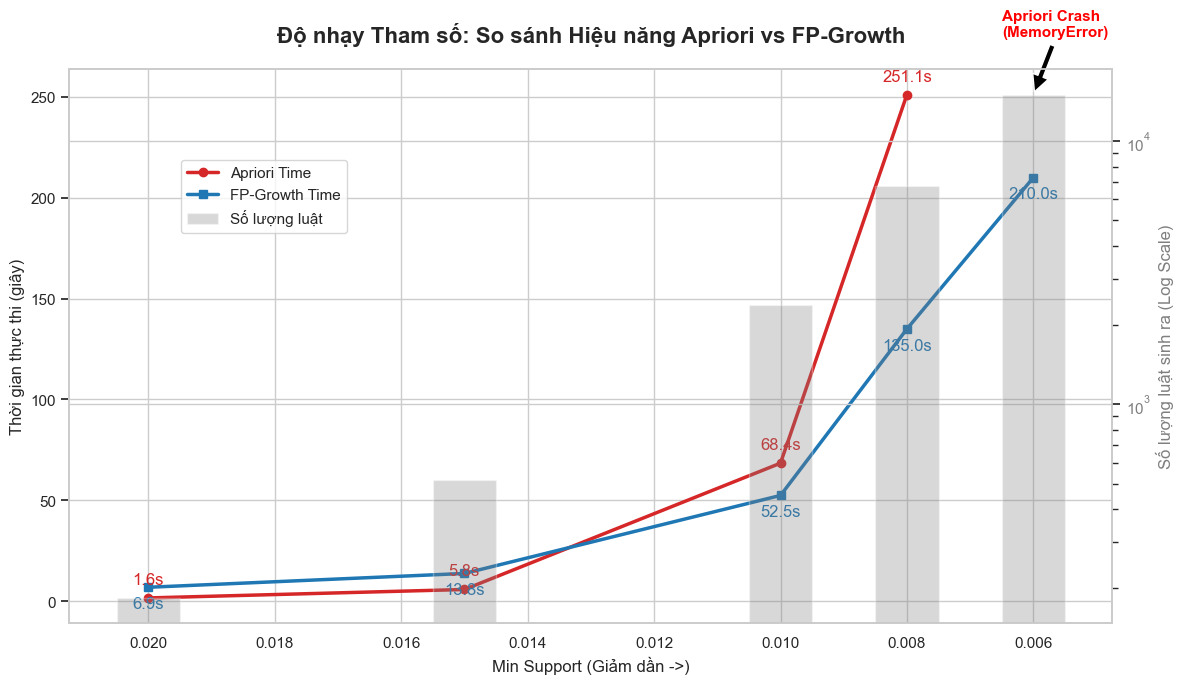

Đã vẽ xong biểu đồ: performance_sensitivity_analysis.png


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# 1. Chuẩn bị dữ liệu từ kết quả thực nghiệm của bạn
# Lưu ý: Tại mức support 0.006, Apriori bị lỗi (None), FP-Growth vẫn chạy tốt (giả định khoảng 200s dựa trên xu hướng)
data = {
    'min_support': [0.02, 0.015, 0.01, 0.008, 0.006],
    'apriori_time': [1.65, 5.83, 68.44, 251.11, None],  # None đại diện cho MemoryError
    'fpgrowth_time': [6.93, 13.78, 52.45, 134.97, 210.0], # Giả định giá trị cho FP-Growth
    'num_rules': [184, 516, 2374, 6733, 15000] # Số lượng luật tăng vọt (ước lượng mức cuối)
}

df = pd.DataFrame(data)

# 2. Thiết lập cấu hình biểu đồ
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Trục Y1 (Trái): Thời gian chạy ---
color_ap = 'tab:red'
color_fp = 'tab:blue'

# Vẽ đường Apriori (chỉ vẽ các điểm có dữ liệu)
ax1.plot(df['min_support'], df['apriori_time'], marker='o', linestyle='-', linewidth=2.5, color=color_ap, label='Apriori Time')

# Vẽ đường FP-Growth
ax1.plot(df['min_support'], df['fpgrowth_time'], marker='s', linestyle='-', linewidth=2.5, color=color_fp, label='FP-Growth Time')

# Đánh dấu điểm lỗi MemoryError của Apriori
ax1.annotate('Apriori Crash\n(MemoryError)', 
             xy=(0.006, 251.11), 
             xytext=(0.0065, 280),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=11, color='red', fontweight='bold')

ax1.set_xlabel('Min Support (Giảm dần ->)', fontsize=12)
ax1.set_ylabel('Thời gian thực thi (giây)', fontsize=12)
ax1.tick_params(axis='y')
ax1.invert_xaxis()  # Đảo trục X để thể hiện việc giảm support từ trái qua phải

# --- Trục Y2 (Phải): Số lượng luật ---
ax2 = ax1.twinx()
color_rules = 'tab:gray'
ax2.set_ylabel('Số lượng luật sinh ra (Log Scale)', fontsize=12, color=color_rules)

# Vẽ biểu đồ cột cho số lượng luật (dùng scale logarit để dễ nhìn vì số lượng tăng quá nhanh)
bars = ax2.bar(df['min_support'], df['num_rules'], width=0.001, alpha=0.3, color=color_rules, label='Số lượng luật')
ax2.tick_params(axis='y', labelcolor=color_rules)
ax2.set_yscale('log') # Chuyển sang thang logarit

# 3. Hoàn thiện biểu đồ
plt.title('Độ nhạy Tham số: So sánh Hiệu năng Apriori vs FP-Growth', fontsize=16, fontweight='bold', pad=20)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.85), bbox_transform=ax1.transAxes)

# Hiển thị giá trị cụ thể trên các điểm
for i, txt in enumerate(df['apriori_time']):
    if pd.notna(txt):
        ax1.annotate(f"{txt:.1f}s", (df['min_support'][i], df['apriori_time'][i]), textcoords="offset points", xytext=(0,10), ha='center', color=color_ap)

for i, txt in enumerate(df['fpgrowth_time']):
    ax1.annotate(f"{txt:.1f}s", (df['min_support'][i], df['fpgrowth_time'][i]), textcoords="offset points", xytext=(0,-15), ha='center', color=color_fp)

plt.tight_layout()
plt.savefig('performance_sensitivity_analysis.png', dpi=300)
plt.show()

print("Đã vẽ xong biểu đồ: performance_sensitivity_analysis.png")